## Orcapod DEMO

A framework for fully traceable and reproducible scientific computation

## Guiding Principles

- Reproducibility
- Performance
- Simplicity
- Flexibility
- Extensibility
- Reusability
- Robustness

## Build (if changed)

In [1]:
!cd ../../.. && maturin develop --uv

  Downloaded backtrace v0.3.75                                             
  Downloaded addr2line v0.24.2                                             
  Downloaded android_system_properties v0.1.5B                             
  Downloaded core-foundation-sys v0.8.745.3KiB                             
  Downloaded core-foundation v0.10.1: 95.4KiB                              
  Downloaded combine v4.6.7ing bytes: 93.7KiB                              
  Downloaded windows-targets v0.42.2: 2.4MiB                               
  Downloaded cesu8 v1.1.0ining bytes: 14.2MiB                              
  Downloaded bumpalo v3.19.0ng bytes: 14.5MiB                              
  Downloaded windows-link v0.1.3ytes: 14.5MiB                              
  Downloaded iana-time-zone-haiku v0.1.2.4MiB                              
  Downloaded webpki-root-certs v0.26.114.4MiB                              
  Downloaded windows-implement v0.60.016.7MiB                              
  Downloaded

## Monitors

In [246]:
# monitor containers
# watch -n 0.5 docker ps -a

# monitor last container
# watch -n 2 'docker logs "$(docker ps -q --latest)"'

# remove closed containers
# docker rm $(dockr ps -a -q)

# monitor agent network

# clear && python -c 'import asyncio; from orcapod import AgentClient; client = AgentClient(group="test", host="alpha"); asyncio.run(client.watch(key_expr="**"))'

## Imports

In [197]:
import asyncio
import csv
import json
import random
from datetime import datetime, timezone
from pathlib import Path
from textwrap import dedent

from orcapod import (
    Agent,
    AgentClient,
    Blob,
    BlobKind,
    InputSpecUri,
    Kernel,
    LocalDockerOrchestrator,
    LocalFileStore,
    OutputSpecUri,
    Packet,
    PathInfo,
    PathSet,
    Pipeline,
    PipelineJob,
    Pod,
    PodJob,
    Uri,
)

## Config

In [3]:
namespace_lookup = {"default": "../../.tmp"}
root_dir = "test"
data_dir = f"{root_dir}/data"
store_dir = f"{root_dir}/store"

In [4]:
group = "test"
host = "alpha"

## Utils

In [5]:
from collections.abc import Awaitable


async def print_crash(long_task: Awaitable):
    try:
        return await long_task
    except Exception as exception:
        print(f"{long_task.__name__} CRASHED: {exception}")

In [6]:
import subprocess
from IPython.display import SVG


def display_dot(dot_data: str):
    svg_bytes, _ = subprocess.Popen(
        ["dot", "-T", "svg"],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    ).communicate(dot_data.encode())

    return SVG(data=svg_bytes)

In [7]:
from IPython.display import display, clear_output
from time import sleep
from collections.abc import Callable


def animate_display(next_display_object: Callable):
    while display_object := next_display_object():
        clear_output()
        display_handle = display(display_id="current")
        display_handle.update(display_object)
        sleep(0.1)

## Setup

Makes parameter files, and some test data.

In [233]:
config_dir = Path(namespace_lookup["default"]) / data_dir / "configs"
config_dir.mkdir(parents=True, exist_ok=True)

# Save parameter files
params = {
    "filter_width": 3,
    "spike_threshold": 3.0,
    "error_threshold": 100.0,
}
with open(config_dir / "1.json", "w") as f:
    json.dump(params, f, indent=2)

params.update({"filter_width": 4})

with open(config_dir / "2.json", "w") as f:
    json.dump(params, f, indent=2)

NUM_FILES = 3  # Later, increase to see error
ERROR_SUBJ = 4


# Generate a dummy ephys trace
def generate_dummy_trace(n_samples=12, seed=0):
    random.seed(seed)

    noise = [random.gauss(0, 0.5) for _ in range(n_samples)]
    spike_train = [0.0] * n_samples
    for _ in range(seed + 1):
        spike_idx = random.randrange(n_samples)
        spike_train[spike_idx] = 10  # fake spike
    trace = [n + s for n, s in zip(noise, spike_train)]

    if seed % 2 == 1:  # For demonstrating speed variance
        trace[0] = 1.0
    if seed == ERROR_SUBJ:  # For later error detection
        trace[3] = 999.0

    return trace


input_dir = Path(namespace_lookup["default"]) / data_dir / "subjects"
input_dir.mkdir(parents=True, exist_ok=True)

for i in range(1, NUM_FILES + 1):
    trace = generate_dummy_trace(seed=i)
    with open(input_dir / f"{i}.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(trace)

`smooth_pod` -  Simple computation that:
- Loads a trace file
- Loads a config file
- Sleep for 10s if the first value is exactly `1`
- Crash if any trace value is greater than `error_threshold`
- Perform smoothing on the trace

In [234]:
smooth_pod = Pod(
    image="python:3.12-slim",
    command=[
        "python",
        "-c",
        dedent(
            """
            import csv
            import json 
            import statistics

            with open("/tmp/input/trace.csv") as f:
                trace = [float(x) for row in csv.reader(f) for x in row if x.strip()]

            with open("/tmp/input/config.json", "r") as f:
                config = json.load(f)

            # Simulated error checks
            if trace and trace[0] == 1.0:
                sleep(10)
            if any(val > config.get("error_threshold", float("inf")) for val in trace):
                raise Exception("Intentional error")

            # Moving average smoothing
            def moving_average(data, width=3):
                smoothed = []
                half = width // 2
                for i in range(len(data)):
                    window = data[max(0, i - half) : min(len(data), i + half + 1)]
                    smoothed.append(statistics.mean(window))
                return smoothed

            filter_width = config.get("filter_width", 3)
            smoothed = moving_average(trace, filter_width)

            with open("/tmp/output/smoothed.csv", "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(smoothed)

            print(f"Trace: {trace}")
            print(f"Config: {config}")
            print(f"Smoothed: {smoothed}")
            """
        ).strip(),
    ],
    input_spec={
        "trace": PathInfo(path="/tmp/input/trace.csv", match_pattern=".*\.csv"),
        "config": PathInfo(path="/tmp/input/config.json", match_pattern=".*\.json"),
    },
    output_dir="/tmp/output/",
    output_spec={"smooth": PathInfo(path="smoothed.csv", match_pattern=".*\.csv")},
    source_commit_url="https://place.holder",
    recommended_cpus=0.1,
    recommended_memory=10 << 20,
)

`spike_pod` -  Simple computation that:
- Loads a trace file
- Loads a config file
- Finds/saves trace indices over `spike_threshold`

In [235]:
spike_pod = Pod(
    image="python:3.13-slim",
    command=[
        "python",
        "-c",
        dedent(
            """ 
            import csv
            import json 

            with open("/tmp/input/smoothed.csv") as f:
                trace = [float(x) for row in csv.reader(f) for x in row if x.strip()]

            with open("/tmp/input/config.json", "r") as f:
                config = json.load(f)

            spike_threshold = config.get("spike_threshold", float("inf"))
            print(f"Trace: {trace}")
            spikes = [i for i, val in enumerate(trace) if val > spike_threshold]

            with open("/tmp/output/spikes.csv", "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(spikes)

            print(f"Spikes: {spikes}")
            """
        ).strip(),
    ],
    input_spec={
        "smoothed": PathInfo(path="/tmp/input/smoothed.csv", match_pattern=".*\.csv"),
        "config": PathInfo(path="/tmp/input/config.json", match_pattern=".*\.json"),
    },
    output_dir="/tmp/output/",
    output_spec={"spikes": PathInfo(path="spikes.csv", match_pattern=".*\.spikes")},
    source_commit_url="https://place.holder",
    recommended_cpus=0.1,
    recommended_memory=10 << 20,
)

In [236]:
orch = LocalDockerOrchestrator()

In [237]:
store = LocalFileStore(directory=f'{Path(namespace_lookup["default"])}/{store_dir}')

## `PodJob` Test

In [238]:
smooth_pod_job = PodJob(
    pod=smooth_pod,
    input_packet=Packet(
        {
            "trace": PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{data_dir}/subjects/2.csv"),
                    checksum="",
                )
            ),
            "config": PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{data_dir}/configs/1.json"),
                    checksum="",
                )
            ),
        }
    ),
    # CB: ideally, I would want to save as /smooth/config1/smooth_subj_1.csv
    output_dir=Uri(namespace="default", path=f"{data_dir}/smooth/sub-2_conf-1"),
    cpu_limit=0.1,
    memory_limit=10 << 20,
    namespace_lookup=namespace_lookup,
)

In [239]:
pod_run = await orch.start(namespace_lookup=namespace_lookup, pod_job=smooth_pod_job)

In [187]:
pod_result = await orch.get_result(namespace_lookup=namespace_lookup, pod_run=pod_run)

In [188]:
pod_result.status

In [189]:
await orch.delete(pod_run=pod_run)

In [ ]:
# REMOVE LATER
# Checking that spikes pod works

spike_pod_job = PodJob(
    pod=spike_pod,
    input_packet=Packet(
        {
            "smoothed": PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(
                        namespace="default", path=f"{data_dir}/smooth/sub-2_conf-1/smoothed.csv"
                    ),
                    checksum="",
                )
            ),
            "config": PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{data_dir}/configs/1.json"),
                    checksum="",
                )
            ),
        }
    ),
    output_dir=Uri(namespace="default", path=f"{data_dir}/spikes/sub-2_conf-1"),
    cpu_limit=0.1,
    memory_limit=10 << 20,
    namespace_lookup=namespace_lookup,
)
pod_run = await orch.start(namespace_lookup=namespace_lookup, pod_job=spike_pod_job)

## `PipelineJob` Test

Configuration for operator that renames packet keys i.e. `MapOperator`.

In [ ]:
map_left = {"answer": "left"}
map_right = {"answer": "right"}

Compute pipeline that chains several `add_pod` computations.

In [241]:
pipeline = Pipeline(
    graph_dot="""
    digraph {
        smooth -> spike
    }
    """,
    metadata={
        "smooth": Kernel.POD(ref=smooth_pod),
        "spike" : Kernel.POD(ref=spike_pod),
    },
    input_spec={
        "smooth": [InputSpecUri(node=f"smooth", key="trace")],
        "spike": [InputSpecUri(node=f"spike", key="smoothed")]
    },
    output_spec={"answer": OutputSpecUri(node="spike", key="spikes")},
)

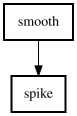

In [242]:
display_dot(dot_data=pipeline.make_dot())

In [53]:
# --- Stop point ---

In [ ]:
pipeline_job = PipelineJob(
    pipeline=pipeline,
    input_packet={
        "trace": [
            PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{data_dir}/subjects/{i}.csv"),
                    checksum="",
                )
            )
            for i in range(1, NUM_FILES+1) 
        ],
        "config": [
            PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{data_dir}/configs/{i}.json"),
                    checksum="",
                )
            )
            for i in [1, 2]
        ],
        # "smoothed" : [
        #     PathSet.UNARY(
        #         blob=Blob(
        #             kind=BlobKind.FILE,
        #             location=Uri(
        #                 namespace="default", 
        #                 # OrcaError : file not exist yet 
        #                 path=f"{data_dir}/smooth/subj-{i}_conf-{j}/smoothed.csv",
        #             ),
        #             checksum="",
        #         )
        #     )
        #     for i in range(1, NUM_FILES+1) for j in [1, 2]
        # ],
    },
    output_dir=Uri(namespace="default", path=f"{data_dir}/spikes"),
    namespace_lookup=namespace_lookup,
)

In [175]:
# pipeline_job.input_packet()
pipeline_job.input_packet()["trace"][0].blob.checksum

'17ffbc3d8a40f546982ea5bea6d725a1c7f42148928cd8a5874d7d673ac5ec5e'

In [243]:
client = AgentClient(group=group, host=host)
agent = Agent(group=group, host=host, orchestrator=orch)

In [244]:
worker = asyncio.create_task(
    print_crash(agent.start(namespace_lookup=namespace_lookup, available_store=store))
)

In [ ]:
pipeline_run = await client.start_pipeline_job(pipeline_job=pipeline_job)


thread 'async-compat/tokio-1' panicked at src/core/pipeline.rs:124:42:
no entry found for key
stack backtrace:
   0: __rustc::rust_begin_unwind
             at /rustc/17067e9ac6d7ecb70e50f92c1944e545188d2359/library/std/src/panicking.rs:697:5
   1: core::panicking::panic_fmt
             at /rustc/17067e9ac6d7ecb70e50f92c1944e545188d2359/library/core/src/panicking.rs:75:14
   2: core::panicking::panic_display
             at /rustc/17067e9ac6d7ecb70e50f92c1944e545188d2359/library/core/src/panicking.rs:261:5
   3: core::option::expect_failed
             at /rustc/17067e9ac6d7ecb70e50f92c1944e545188d2359/library/core/src/option.rs:2024:5
   4: core::option::Option<T>::expect
             at /home/ubuntu/.rustup/toolchains/1.87.0-x86_64-unknown-linux-gnu/lib/rustlib/src/rust/library/core/src/option.rs:933:21
   5: <std::collections::hash::map::HashMap<K,V,S> as core::ops::index::Index<&Q>>::index
             at /home/ubuntu/.rustup/toolchains/1.87.0-x86_64-unknown-linux-gnu/lib/rustlib

In [ ]:
{
    "created": pipeline_run.created(),
    "status": pipeline_run.status(),
    "terminated": pipeline_run.terminated(),
}

In [ ]:
animate_display(
    next_display_object=lambda: (
        display_dot(dot_data=pipeline_run.summarize_dot())
        if not pipeline_run.terminated()
        or datetime.now(timezone.utc).timestamp() <= pipeline_run.terminated() + 2
        else None
    )
)

In [ ]:
pipeline_result = await client.get_pipeline_result(pipeline_run=pipeline_run)

In [ ]:
{
    "created": pipeline_result.created,
    "status": pipeline_result.status,
    "terminated": pipeline_result.terminated,
}

In [ ]:
# print(pipeline_run.summarize_dot())

## Roadmap

- Educational / Pitching Content
- Simpler, python-friendly experience
- Pipeline of pipelines
- Kubernetes orchestrator
- Queries and data exploration
- Dashboard GUIs
- Multi-agent support
- Tags
- Memoization
- Filter operator
- Agent resource limits
- Support external extensibility

## Competitor Review

- DataJoint
- Flyte
- Prefect
- ZenML

Many more in [awesome-pipeline](https://github.com/pditommaso/awesome-pipeline)

## Teardown

In [ ]:
import shutil

In [ ]:
shutil.rmtree(Path(namespace_lookup["default"]) / data_dir / "output")

In [ ]:
shutil.rmtree(Path(namespace_lookup["default"]) / root_dir)